In [1]:
# LOAD Packages (copied from initial training script)
import numpy as np
from collections import namedtuple, OrderedDict

import matplotlib
from mpl_toolkits.mplot3d import Axes3D
import os
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import json
import h5py
import glob
import sys
from mpl_toolkits.axes_grid1 import make_axes_locatable
#!pip install plotly
import plotly
import plotly.graph_objects as go

#import MinkowskiEngine as ME
#sys.path.insert(0, '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/spine/')
#from spine.model.layer.cnn.encoder import SparseResidualEncoder

#sys.path.insert(0, '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/')
#import models.sheep_cnn
#sys.path.insert(0, '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/utils')
#from parse_yaml import ParseYAML

#import gc

#gc.collect()
#torch.cuda.empty_cache()

In [9]:
#batch_stats_log = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_ON_MESYNCBN_MOMENTUM_0.1_LOG_BATCH_STATS/logs/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_ON_MESYNCBN_MOMENTUM_0.1_LOG_BATCH_STATS_default_batch_stats_log.csv'
#train_log = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_ON_MESYNCBN_MOMENTUM_0.1_LOG_BATCH_STATS/logs/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_ON_MESYNCBN_MOMENTUM_0.1_LOG_BATCH_STATS_default_train_log.csv'

# Momentum NONE, LR 0.0001, Batch Size 3125
#batch_stats_log = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_ON_MESYNCBN_MOMENTUM_NONE_LOG_BATCH_STATS_BS_3125_num_workers_16_LR_0.0001/logs/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_ON_MESYNCBN_MOMENTUM_NONE_LOG_BATCH_STATS_BS_3125_num_workers_16_LR_0.0001_default_batch_stats_log.csv'
#train_log = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_ON_MESYNCBN_MOMENTUM_NONE_LOG_BATCH_STATS_BS_3125_num_workers_16_LR_0.0001/logs/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_ON_MESYNCBN_MOMENTUM_NONE_LOG_BATCH_STATS_BS_3125_num_workers_16_LR_0.0001_default_train_log.csv'

# Momentum 0.01, LR 0.0001, Batch Size 3125
batch_stats_log = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_ON_MESYNCBN_MOMENTUM_0.01_LOG_BATCH_STATS_BS_3125_num_workers_16_LR_0.0001/logs/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_ON_MESYNCBN_MOMENTUM_0.01_LOG_BATCH_STATS_BS_3125_num_workers_16_LR_0.0001_default_batch_stats_log.csv'
train_log = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_ON_MESYNCBN_MOMENTUM_0.01_LOG_BATCH_STATS_BS_3125_num_workers_16_LR_0.0001/logs/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_ON_MESYNCBN_MOMENTUM_0.01_LOG_BATCH_STATS_BS_3125_num_workers_16_LR_0.0001_default_train_log.csv'

# Momentum NONE, LR 0.001, Batch Size 3125
#batch_stats_log = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_ON_MESYNCBN_MOMENTUM_NONE_LOG_BATCH_STATS_BS_3125_num_workers_16/logs/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_ON_MESYNCBN_MOMENTUM_NONE_LOG_BATCH_STATS_BS_3125_num_workers_16_default_batch_stats_log.csv'
#train_log = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_ON_MESYNCBN_MOMENTUM_NONE_LOG_BATCH_STATS_BS_3125_num_workers_16/logs/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_ON_MESYNCBN_MOMENTUM_NONE_LOG_BATCH_STATS_BS_3125_num_workers_16_default_train_log.csv'

# 100k Sample, Momentum 0.01, LR 0.0001, Batch Size 3200, MSE Loss, Linear Energy Scale
batch_stats_log_MSE_LIN = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-MSELOSS-LinearEnergyScale-100kSamples-BUGFIX/logs/ddp-shifter-MSELOSS-LinearEnergyScale-100kSamples-BUGFIX_default_batch_stats_log.csv'
train_log_MSE_LIN = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-MSELOSS-LinearEnergyScale-100kSamples-BUGFIX/logs/ddp-shifter-MSELOSS-LinearEnergyScale-100kSamples-BUGFIX_default_train_log.csv'

# 100k Sample, Momentum 0.01, LR 0.0001, Batch Size 3200, MSE Loss, Linear Energy Scale
batch_stats_log = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-MSELOSS-LinearEnergyScale-100kSamples-LR_SCHEDULE_20_0p001_decrease/logs/ddp-shifter-MSELOSS-LinearEnergyScale-100kSamples-LR_SCHEDULE_20_0p001_decrease_default_batch_stats_log.csv'
train_log_MSE_LIN_LR = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-MSELOSS-LinearEnergyScale-100kSamples-LR_SCHEDULE_20_0p001_decrease/logs/ddp-shifter-MSELOSS-LinearEnergyScale-100kSamples-LR_SCHEDULE_20_0p001_decrease_default_train_log.csv'

# 100k Sample, Momentum 0.01, LR 0.0001, Batch Size 3200, L1 Loss, Linear Energy Scale
batch_stats_log_L1_LIN = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-L1LOSS-LinearEnergyScale-100kSamples/logs/ddp-shifter-L1LOSS-LinearEnergyScale-100kSamples_default_batch_stats_log.csv'
train_log_L1_LIN = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-L1LOSS-LinearEnergyScale-100kSamples/logs/ddp-shifter-L1LOSS-LinearEnergyScale-100kSamples_default_train_log.csv'

# 100k Sample, Momentum 0.01, LR 0.0001, Batch Size 3200, Huber Loss, Linear Energy Scale
batch_stats_log_HUBER_LIN = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-HUBERLOSS-LinearEnergyScale-100kSamples/logs/ddp-shifter-HUBERLOSS-LinearEnergyScale-100kSamples_default_batch_stats_log.csv'
train_log_HUBER_LIN = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-HUBERLOSS-LinearEnergyScale-100kSamples/logs/ddp-shifter-HUBERLOSS-LinearEnergyScale-100kSamples_default_train_log.csv'

# 100k Sample, Momentum 0.01, LR 0.0001, Batch Size 3200, MSE Loss, Log Energy Scale
batch_stats_log_MSE_LOG = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-MSELOSS-LogEnergyScale-100kSamples/logs/ddp-shifter-MSELOSS-LogEnergyScale-100kSamples_default_batch_stats_log.csv'
train_log_MSE_LOG = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-MSELOSS-LogEnergyScale-100kSamples/logs/ddp-shifter-MSELOSS-LogEnergyScale-100kSamples_default_train_log.csv'

# 100k Sample, Momentum 0.01, LR 0.0001, Batch Size 3200, L1 Loss, Log Energy Scale
batch_stats_log_L1_LOG = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-L1LOSS-LogEnergyScale-100kSamples/logs/ddp-shifter-L1LOSS-LogEnergyScale-100kSamples_default_batch_stats_log.csv'
train_log_L1_LOG = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-L1LOSS-LogEnergyScale-100kSamples/logs/ddp-shifter-L1LOSS-LogEnergyScale-100kSamples_default_train_log.csv'

# 100k Sample, Momentum 0.01, LR 0.0001, Batch Size 3200, Huber Loss, Log Energy Scale
batch_stats_log_HUBER_LOG = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-HUBERLOSS-LogEnergyScale-100kSamples/logs/ddp-shifter-HUBERLOSS-LogEnergyScale-100kSamples_default_batch_stats_log.csv'
train_log_HUBER_LOG = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-HUBERLOSS-LogEnergyScale-100kSamples/logs/ddp-shifter-HUBERLOSS-LogEnergyScale-100kSamples_default_train_log.csv'

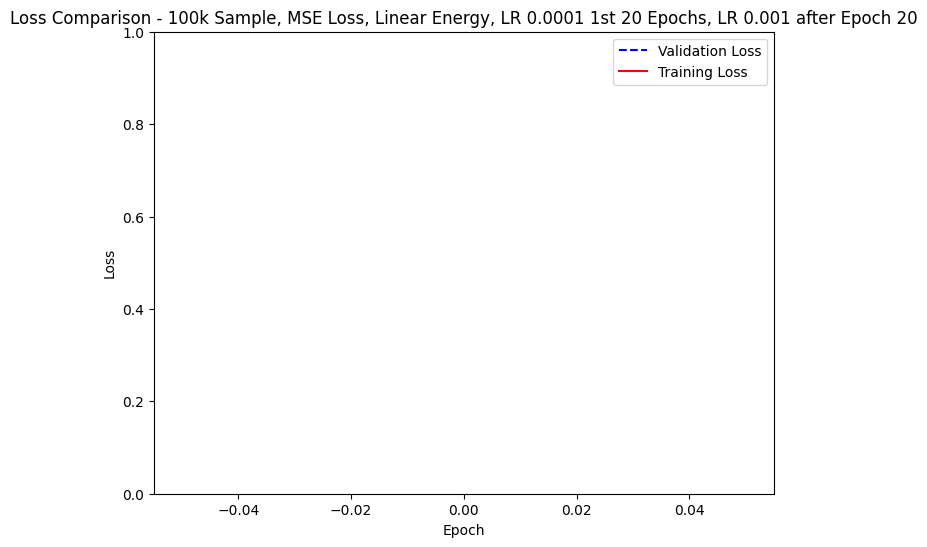

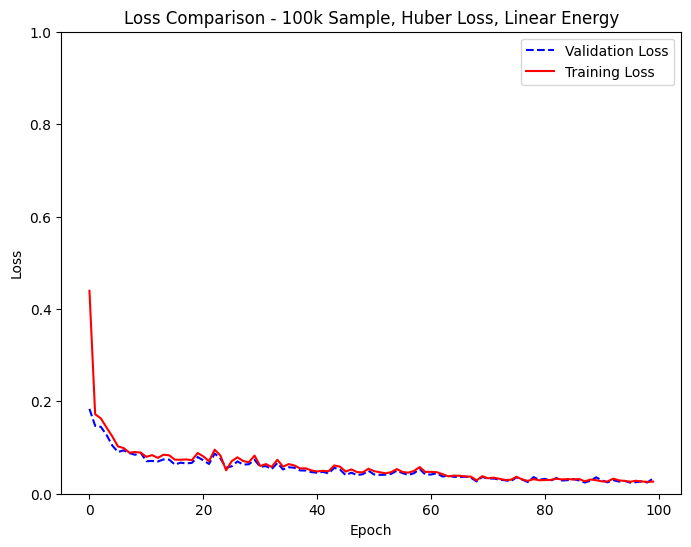

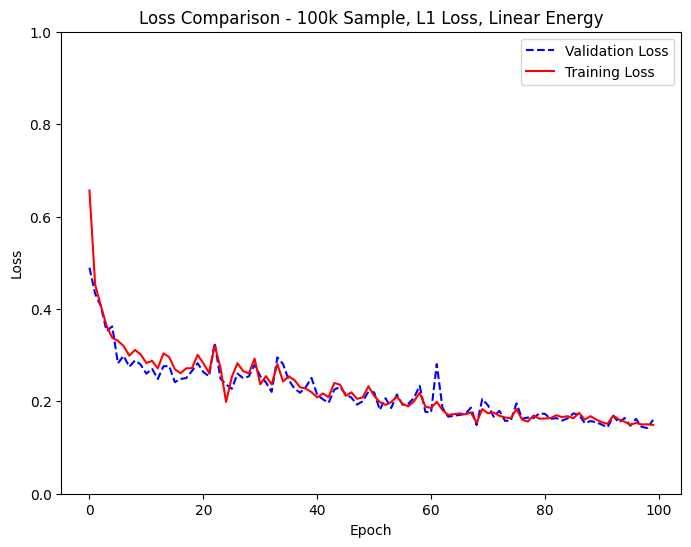

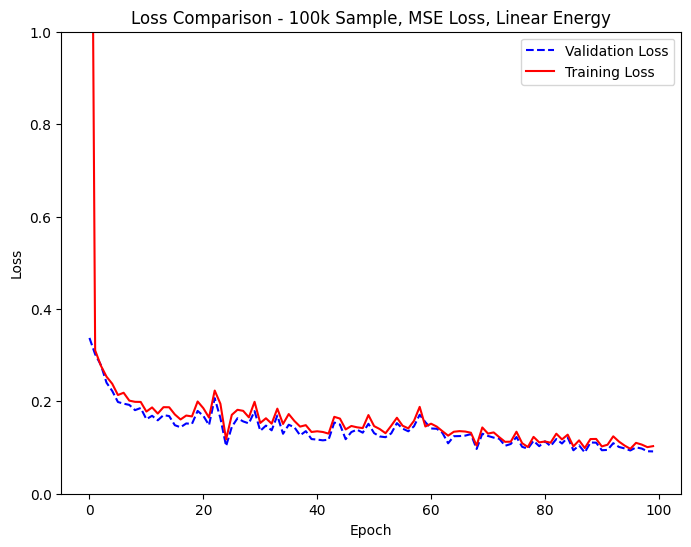

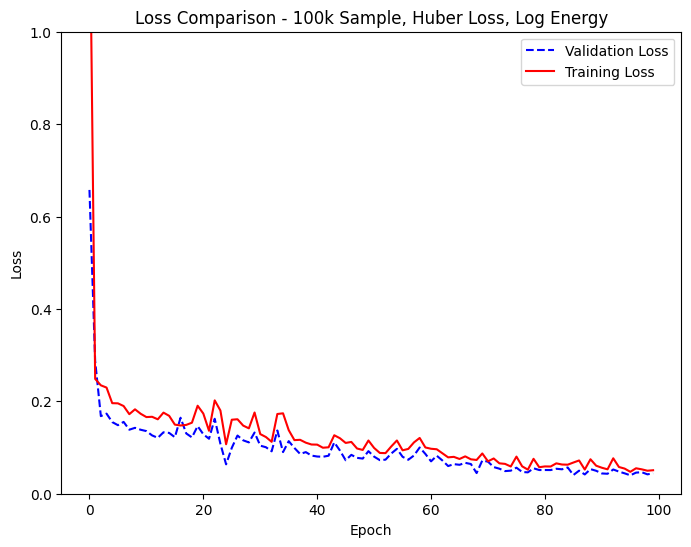

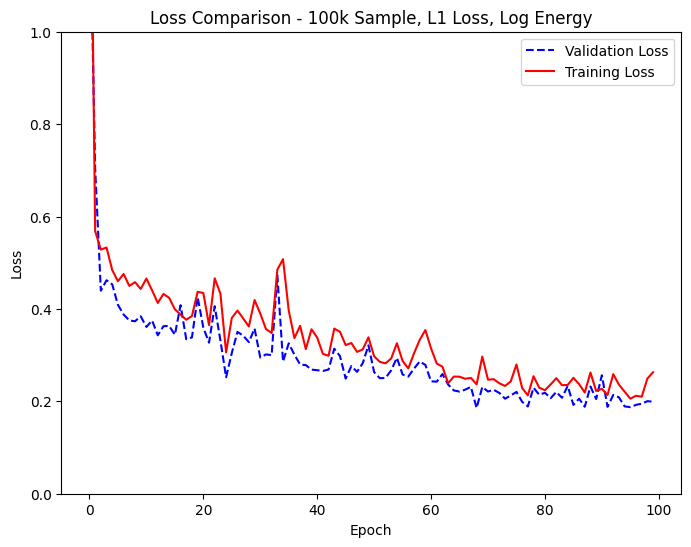

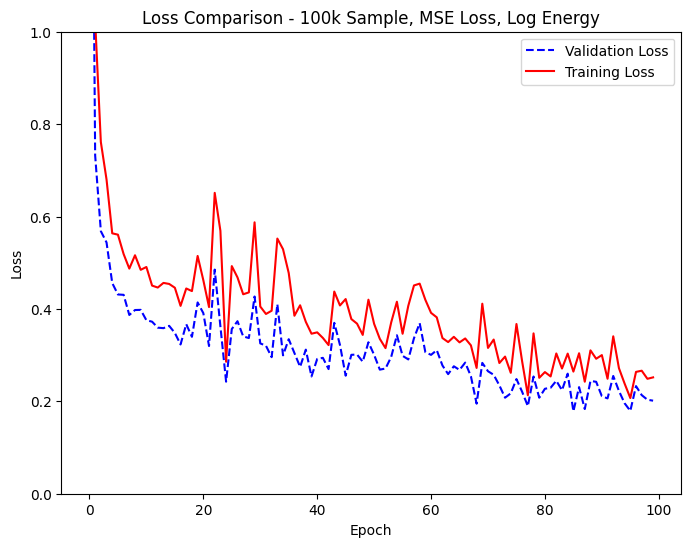

In [10]:
import csv


def plot_train_val_loss(log_file, title):

    epochs = []
    val_loss = []
    train_loss = []
    with open(log_file, 'r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            epochs.append(int(row['epoch']))
            val_loss.append(float(row['val_loss']))
            train_loss.append(float(row['train_loss']))

    fig, ax = plt.subplots(figsize=(8,6))
    ax.plot(epochs, val_loss, label='Validation Loss', color='blue', linestyle='--')
    ax.plot(epochs, train_loss, label='Training Loss', color='red', linestyle='-')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Loss Comparison - ' + title)
    ax.legend()
    ax.set_ylim(0, 1)
    #ax.set_yscale('log')
    plt.show()

plot_train_val_loss(train_log_MSE_LIN_LR, title='100k Sample, MSE Loss, Linear Energy, LR 0.0001 1st 20 Epochs, LR 0.001 after Epoch 20')
plot_train_val_loss(train_log_HUBER_LIN, title='100k Sample, Huber Loss, Linear Energy')
plot_train_val_loss(train_log_L1_LIN, title='100k Sample, L1 Loss, Linear Energy')
plot_train_val_loss(train_log_MSE_LIN, title='100k Sample, MSE Loss, Linear Energy')

plot_train_val_loss(train_log_HUBER_LOG, title='100k Sample, Huber Loss, Log Energy')
plot_train_val_loss(train_log_L1_LOG, title='100k Sample, L1 Loss, Log Energy')
plot_train_val_loss(train_log_MSE_LOG, title='100k Sample, MSE Loss, Log Energy')

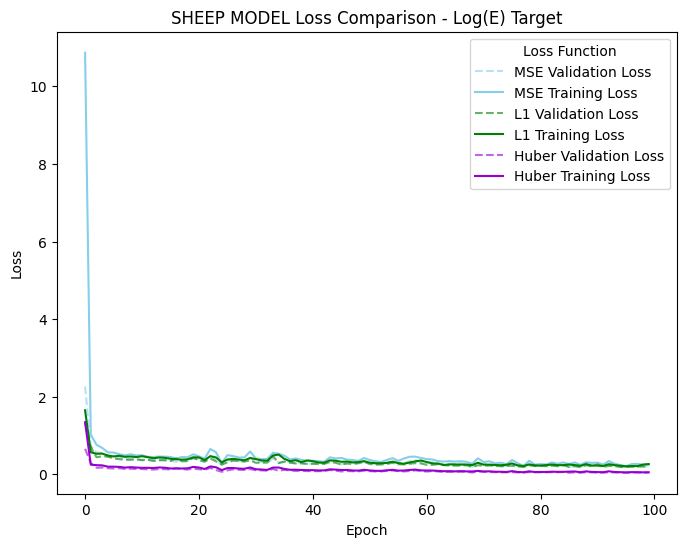

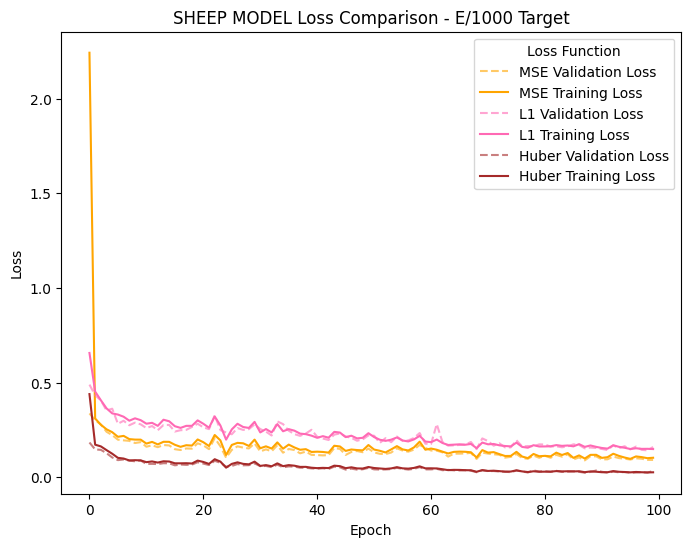

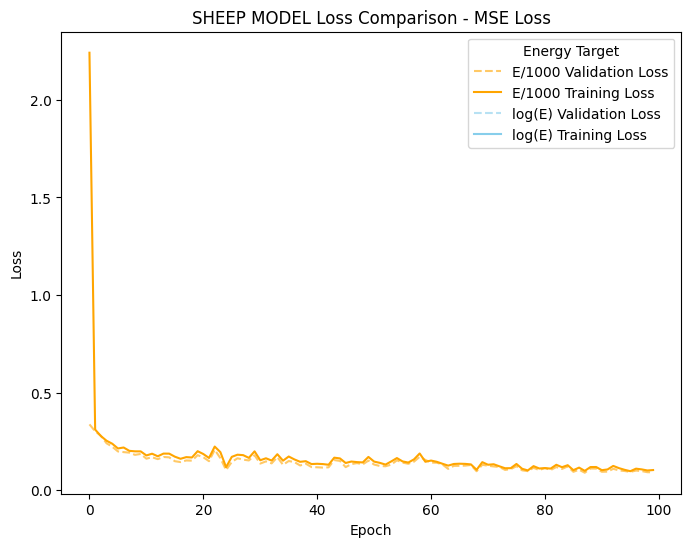

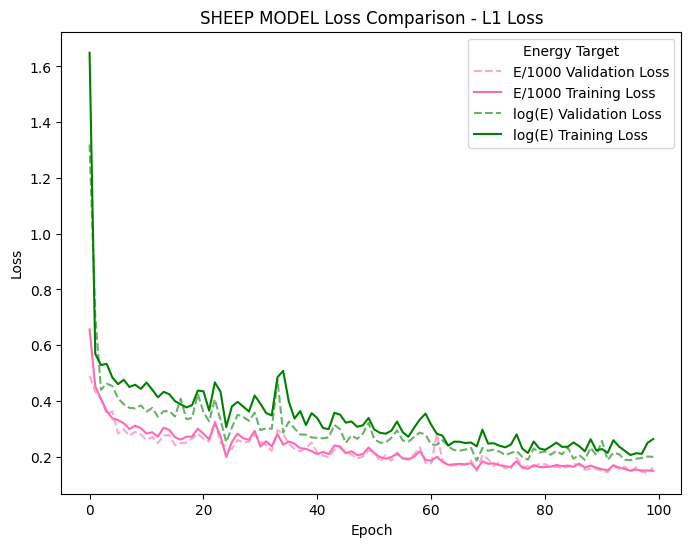

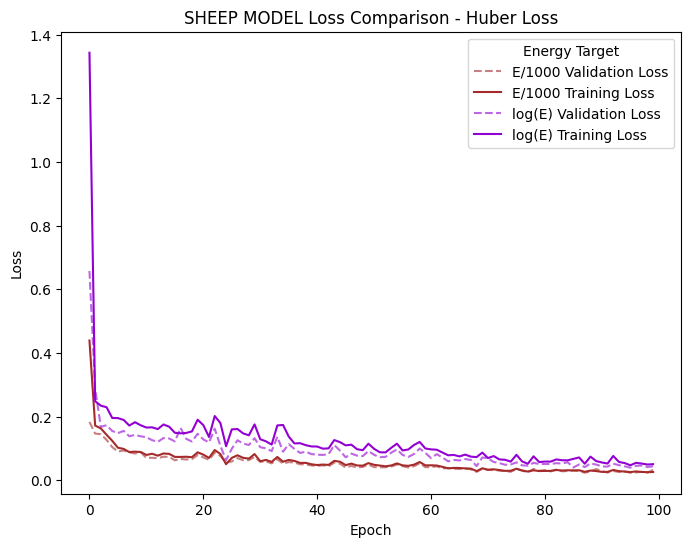

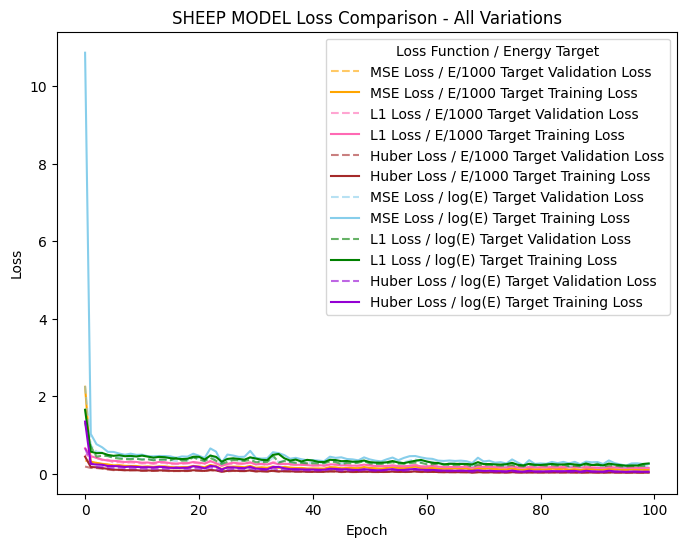

In [11]:
def plot_train_val_loss_comparisons(log_files, labels, colors, title, legend_title=None,ymax=None, log_scale=False):

    fig, ax = plt.subplots(figsize=(8,6))
    
    #print("Title: ", title)
    for i in range(len(log_files)):

        epochs = []
        val_loss = []
        train_loss = []
        with open(log_files[i], 'r') as f:
            reader = csv.DictReader(f)
            for row in reader:
                epochs.append(int(row['epoch']))
                val_loss.append(float(row['val_loss']))
                train_loss.append(float(row['train_loss']))

        #print("Label: ", labels[i])
        #print("Log file: ", log_files[i])
        #print("Color: ", colors[i])

        ax.plot(epochs, val_loss, label=labels[i] + ' Validation Loss', color=colors[i], linestyle='--', alpha=0.6)
        ax.plot(epochs, train_loss, label=labels[i] + ' Training Loss', color=colors[i], linestyle='-')
    
    
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('SHEEP MODEL Loss Comparison - ' + title)
    ax.legend(title=legend_title)
    if ymax is not None:
        ax.set_ylim(0, ymax)
    if log_scale:
        ax.set_yscale('log')
    plt.show()

# Compare between different loss functions for log / linear energy scales
logE_train_logs = [train_log_MSE_LOG, train_log_L1_LOG, train_log_HUBER_LOG]
logE_train_logs_labels = ['MSE', 'L1', 'Huber']
logE_train_logs_colors = ['skyblue', 'green', 'darkviolet']


linE_train_logs = [train_log_MSE_LIN, train_log_L1_LIN, train_log_HUBER_LIN]
linE_train_logs_labels = ['MSE', 'L1', 'Huber']
linE_train_logs_colors = ['orange', 'hotpink', 'brown']

# Compare between different energy scale choices functions for different loss functions 
MSE_loss_train_logs = [train_log_MSE_LIN, train_log_MSE_LIN_LR]
MSE_loss_train_logs_labels = ['E/1000', 'log(E)']
MSE_loss_train_logs_colors = ['orange', 'skyblue']

L1_loss_train_logs = [train_log_L1_LIN, train_log_L1_LOG]
L1_loss_train_logs_labels = ['E/1000', 'log(E)']
L1_loss_train_logs_colors = ['hotpink', 'green']

HUBER_loss_train_logs = [train_log_HUBER_LIN, train_log_HUBER_LOG]
HUBER_loss_train_logs_labels = ['E/1000', 'log(E)']
HUBER_loss_train_logs_colors = ['brown', 'darkviolet']

# Compare all loss function/energy scale combinations
all_train_logs = [train_log_MSE_LIN, train_log_L1_LIN, train_log_HUBER_LIN, train_log_MSE_LOG, train_log_L1_LOG, train_log_HUBER_LOG]
all_train_logs_labels = ['MSE Loss / E/1000 Target', 'L1 Loss / E/1000 Target', 'Huber Loss / E/1000 Target', 'MSE Loss / log(E) Target', 'L1 Loss / log(E) Target', 'Huber Loss / log(E) Target']
all_train_logs_colors = ['orange', 'hotpink', 'brown', 'skyblue', 'green', 'darkviolet']

# Initial Plots (Full Scale All)
plot_train_val_loss_comparisons(logE_train_logs, logE_train_logs_labels, logE_train_logs_colors, title='Log(E) Target', legend_title='Loss Function', ymax=None, log_scale=False)
plot_train_val_loss_comparisons(linE_train_logs, linE_train_logs_labels, linE_train_logs_colors, title='E/1000 Target', legend_title='Loss Function', ymax=None, log_scale=False)

plot_train_val_loss_comparisons(MSE_loss_train_logs, MSE_loss_train_logs_labels, MSE_loss_train_logs_colors, title='MSE Loss', legend_title='Energy Target', ymax=None, log_scale=False)
plot_train_val_loss_comparisons(L1_loss_train_logs, L1_loss_train_logs_labels, L1_loss_train_logs_colors, title='L1 Loss', legend_title='Energy Target', ymax=None, log_scale=False)
plot_train_val_loss_comparisons(HUBER_loss_train_logs, HUBER_loss_train_logs_labels, HUBER_loss_train_logs_colors, title='Huber Loss', legend_title='Energy Target', ymax=None, log_scale=False)

plot_train_val_loss_comparisons(all_train_logs, all_train_logs_labels, all_train_logs_colors, title='All Variations', legend_title='Loss Function / Energy Target', ymax=None, log_scale=False)


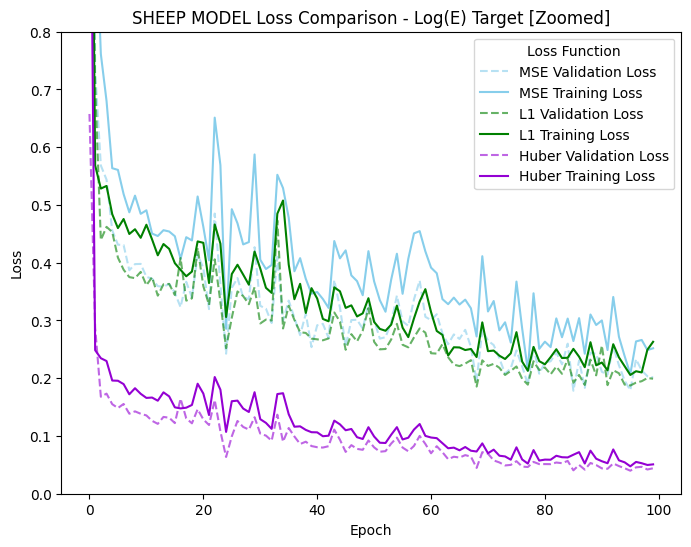

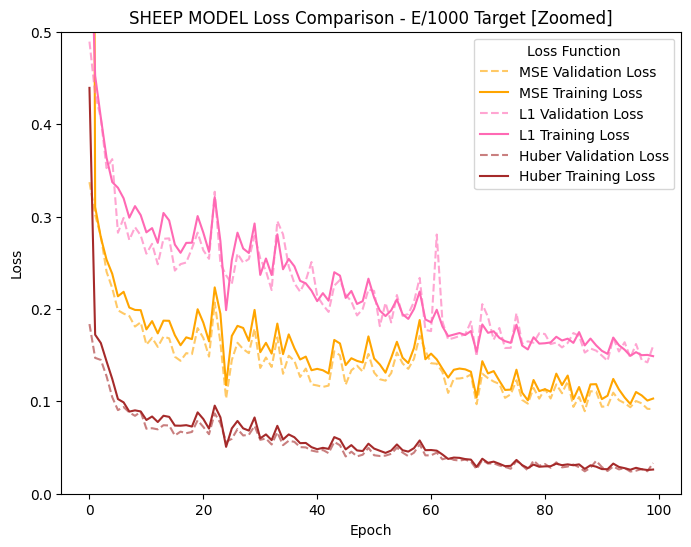

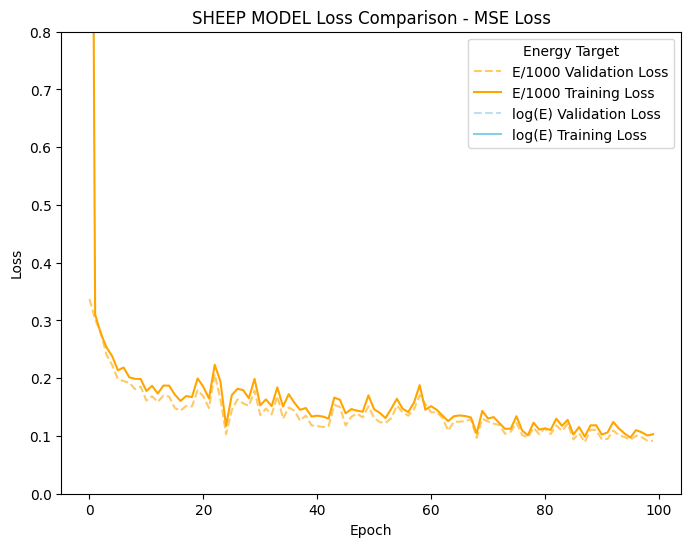

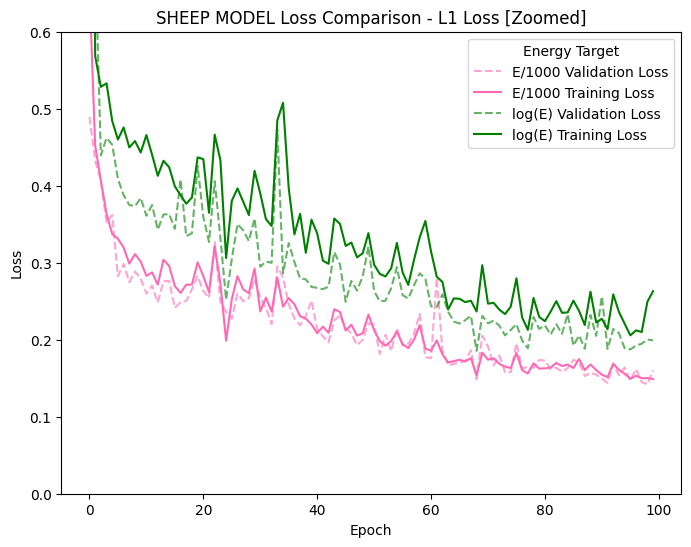

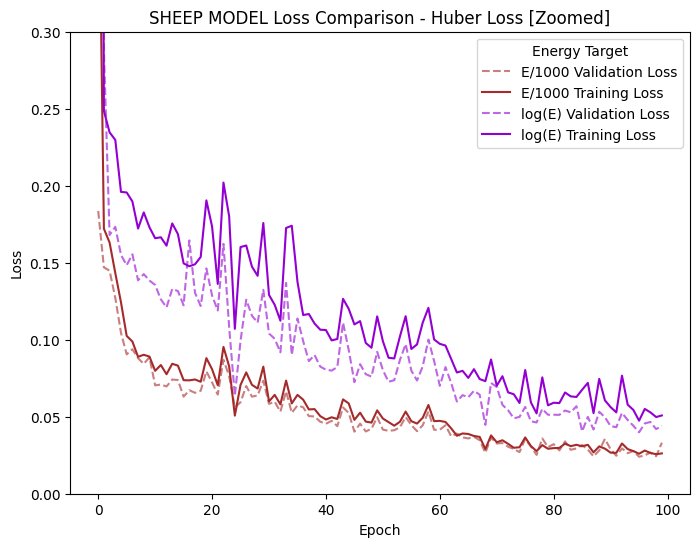

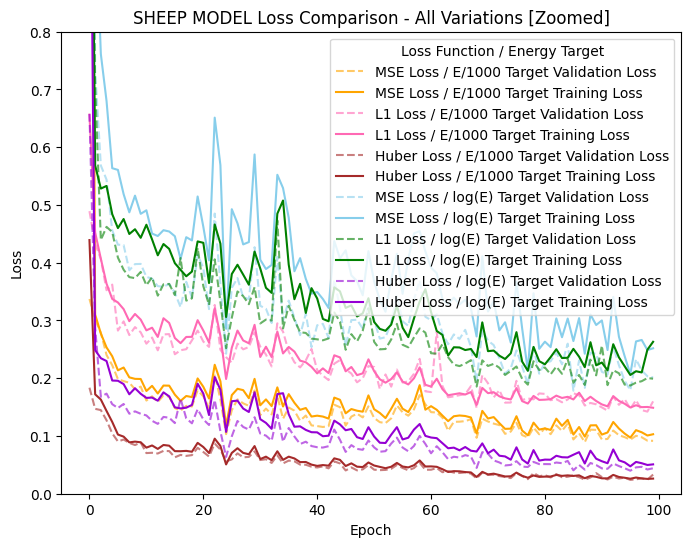

In [12]:
# Zoom in all plots
plot_train_val_loss_comparisons(logE_train_logs, logE_train_logs_labels, logE_train_logs_colors, title='Log(E) Target [Zoomed]', legend_title='Loss Function', ymax=0.8, log_scale=False)
plot_train_val_loss_comparisons(linE_train_logs, linE_train_logs_labels, linE_train_logs_colors, title='E/1000 Target [Zoomed]', legend_title='Loss Function', ymax=0.5, log_scale=False)

plot_train_val_loss_comparisons(MSE_loss_train_logs, MSE_loss_train_logs_labels, MSE_loss_train_logs_colors, title='MSE Loss', legend_title='Energy Target', ymax=0.8, log_scale=False)
plot_train_val_loss_comparisons(L1_loss_train_logs, L1_loss_train_logs_labels, L1_loss_train_logs_colors, title='L1 Loss [Zoomed]', legend_title='Energy Target', ymax=0.6, log_scale=False)
plot_train_val_loss_comparisons(HUBER_loss_train_logs, HUBER_loss_train_logs_labels, HUBER_loss_train_logs_colors, title='Huber Loss [Zoomed]', legend_title='Energy Target', ymax=0.3, log_scale=False)

plot_train_val_loss_comparisons(all_train_logs, all_train_logs_labels, all_train_logs_colors, title='All Variations [Zoomed]', legend_title='Loss Function / Energy Target', ymax=0.8, log_scale=False)


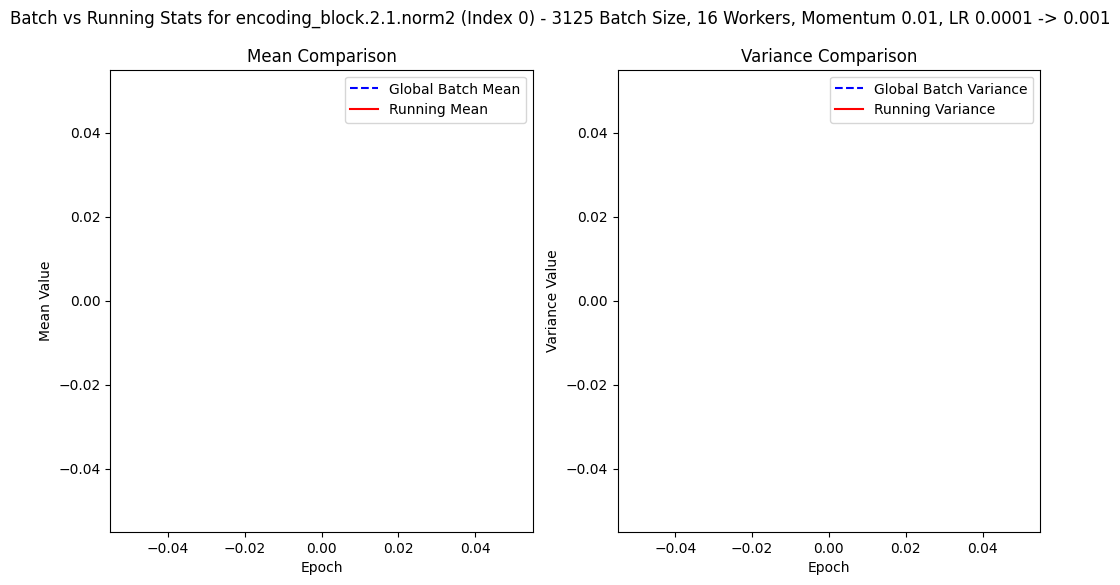

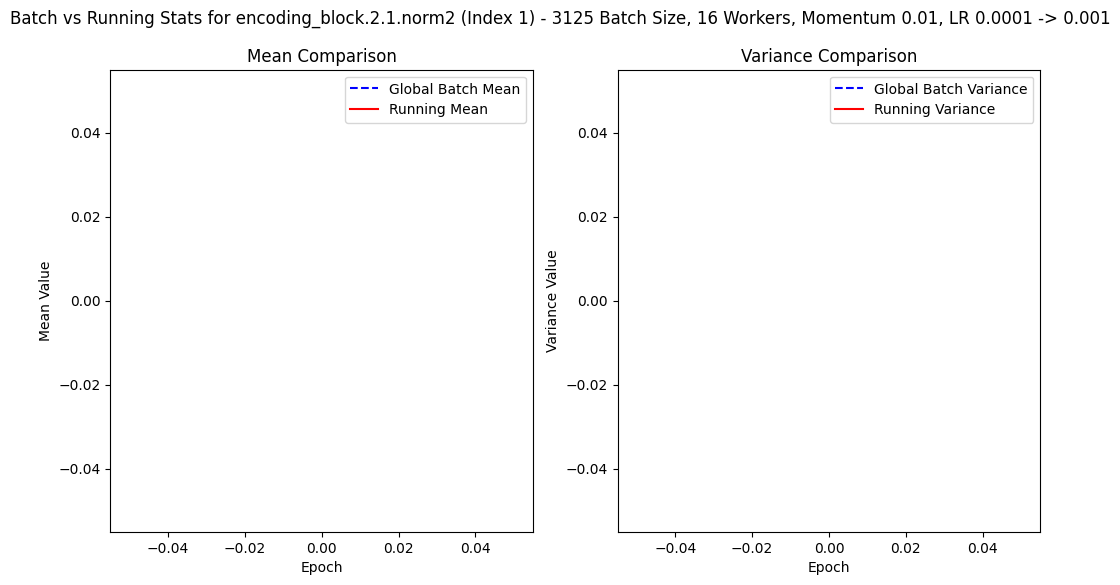

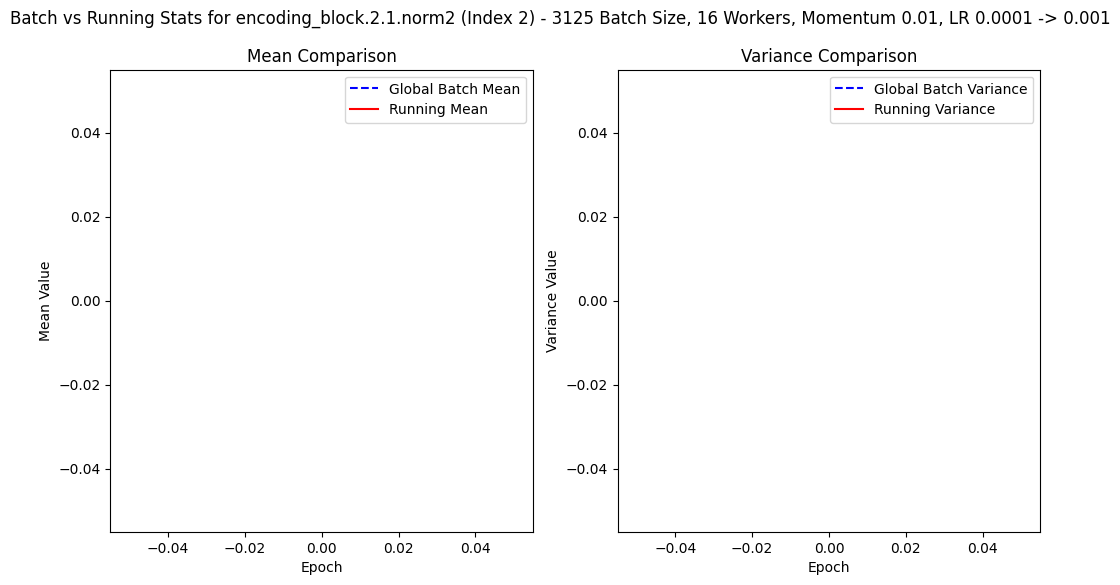

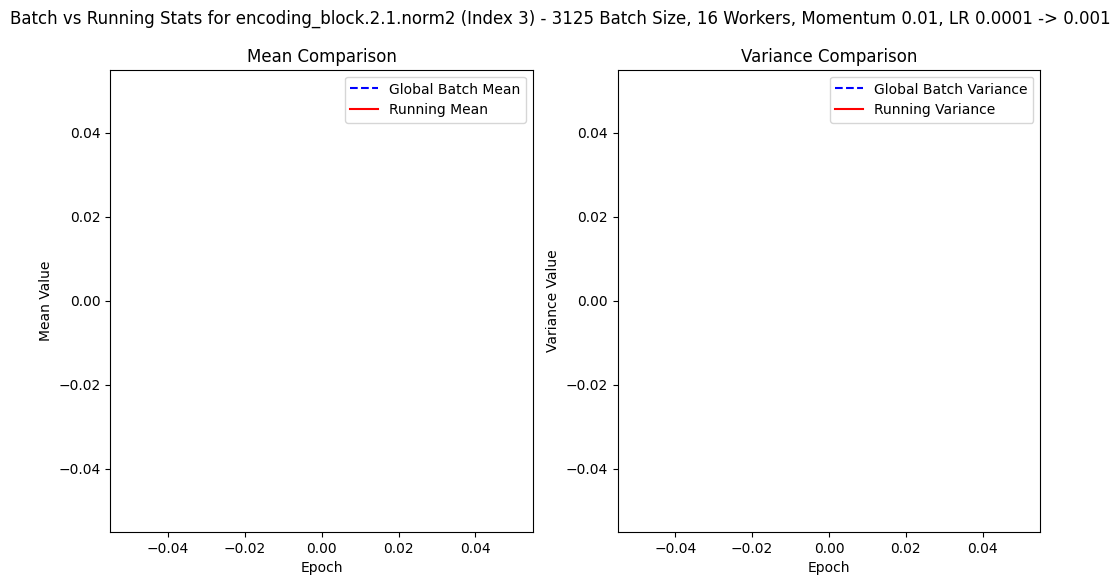

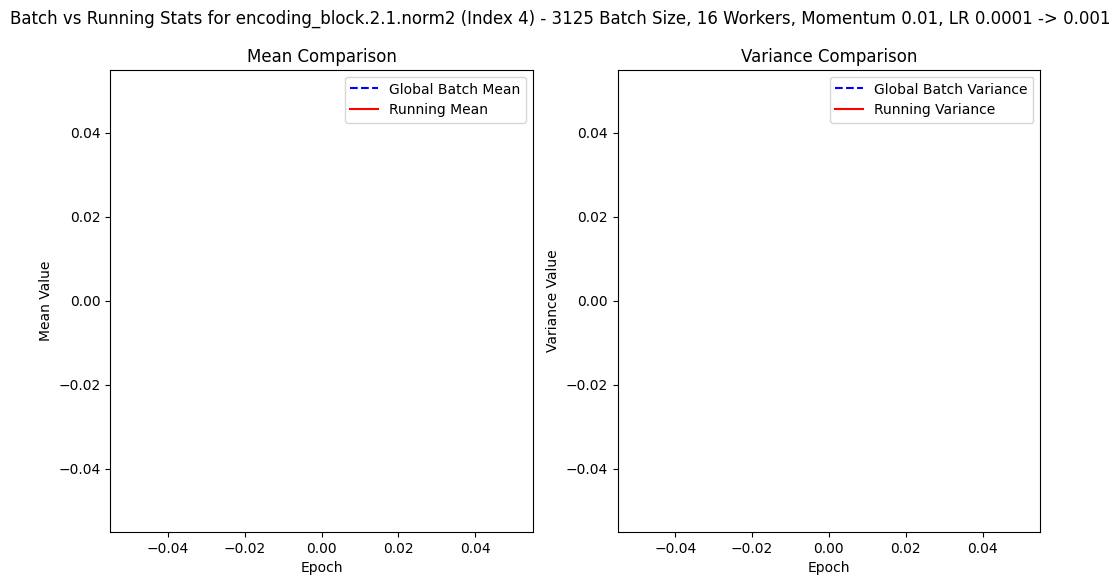

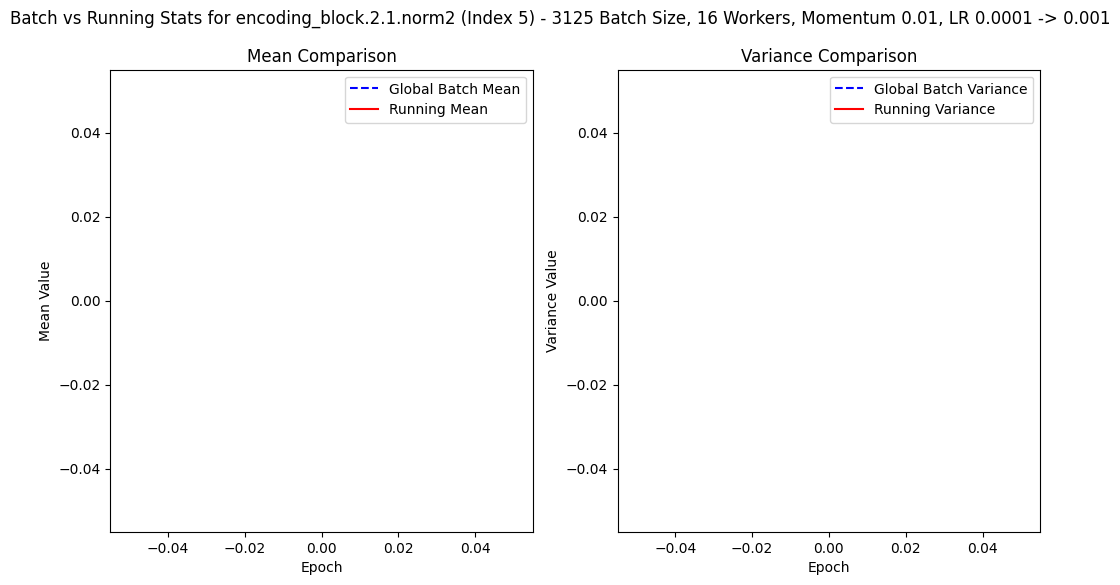

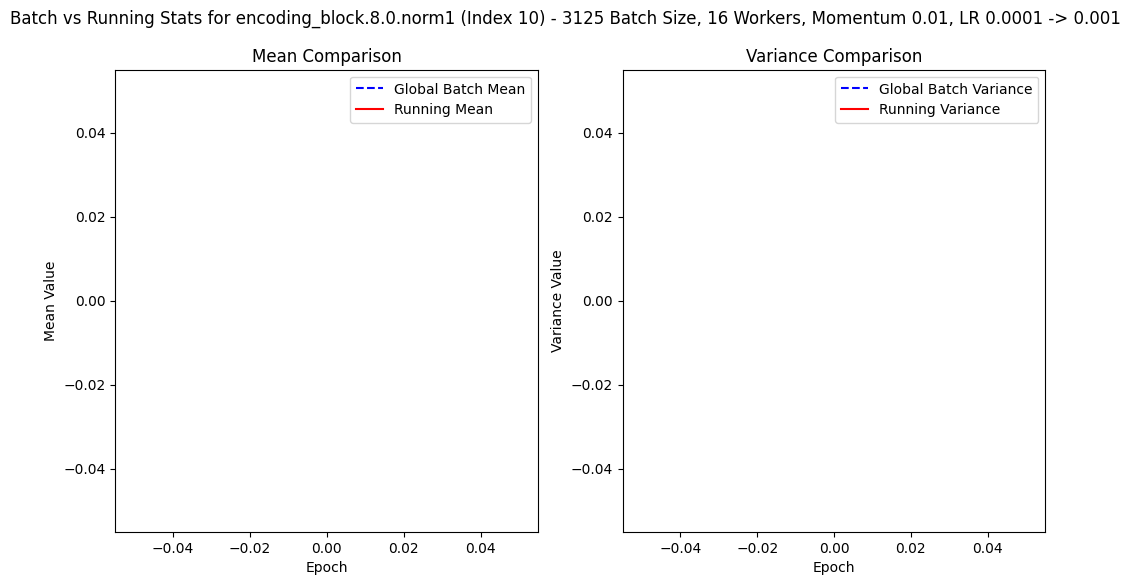

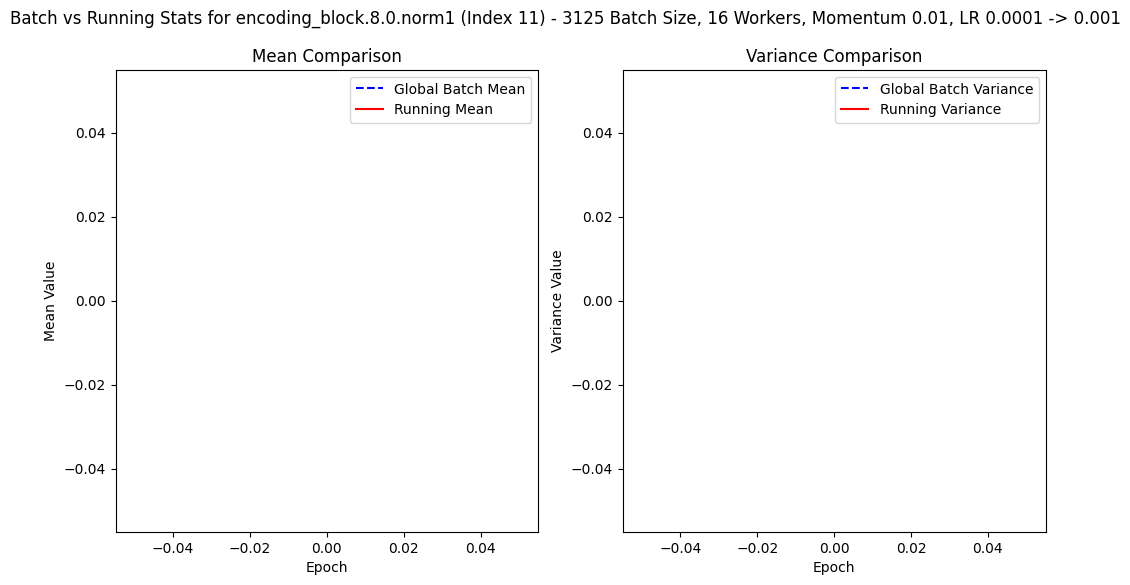

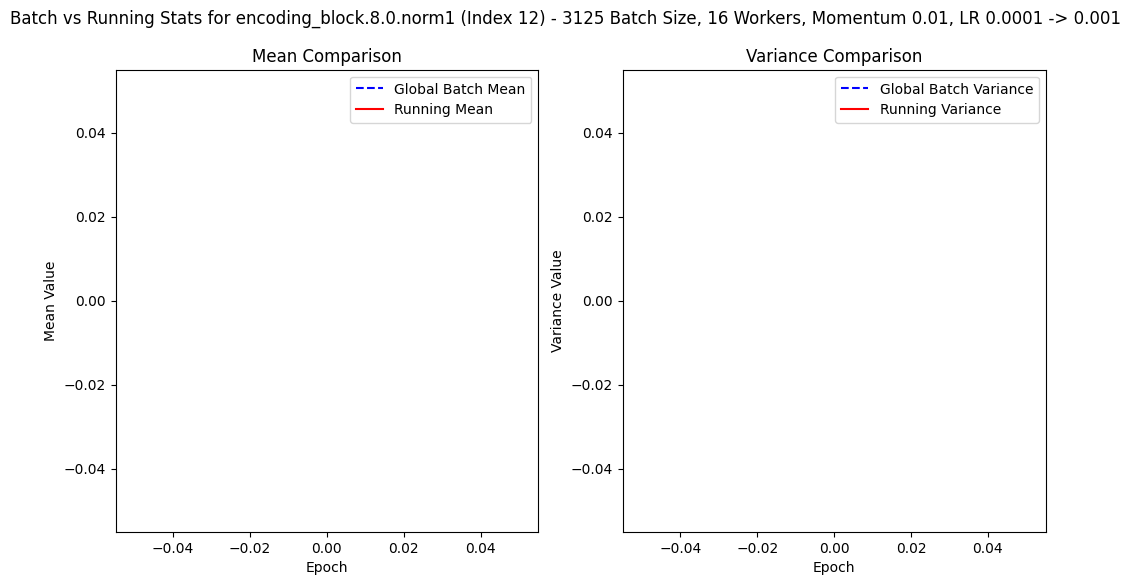

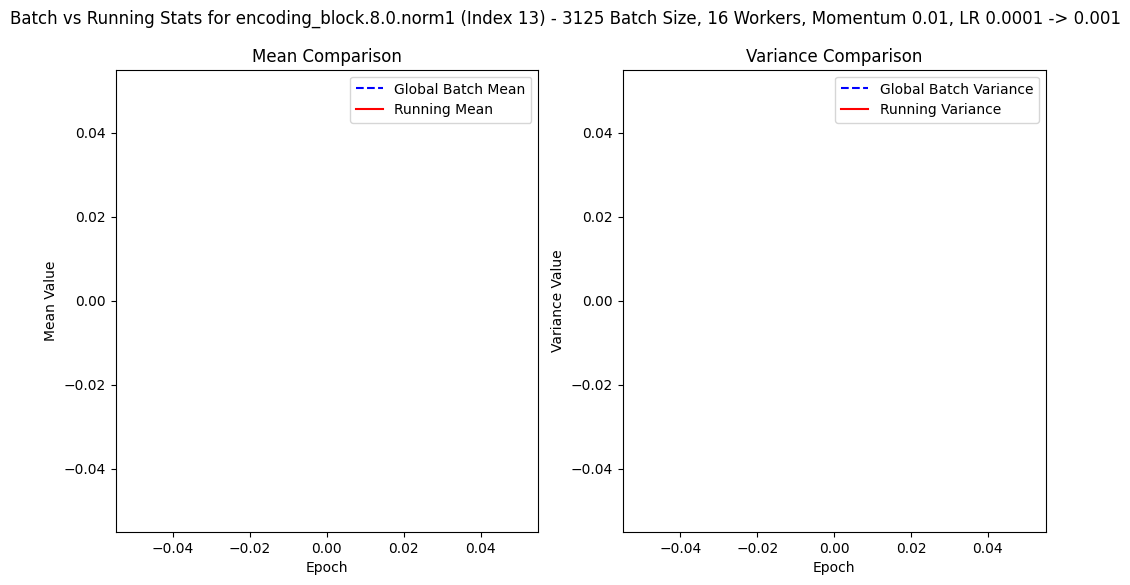

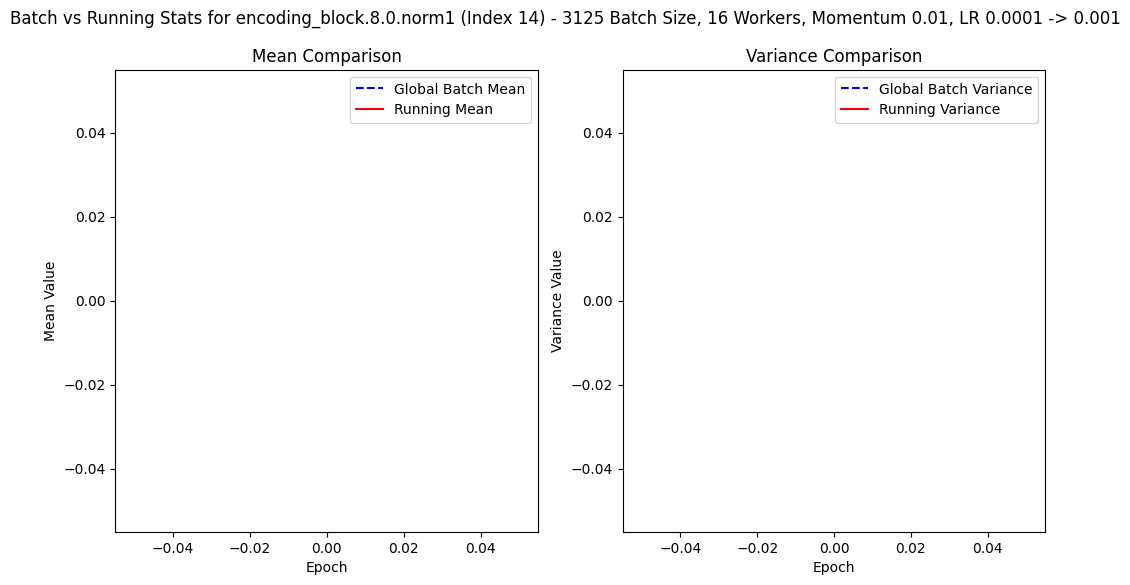

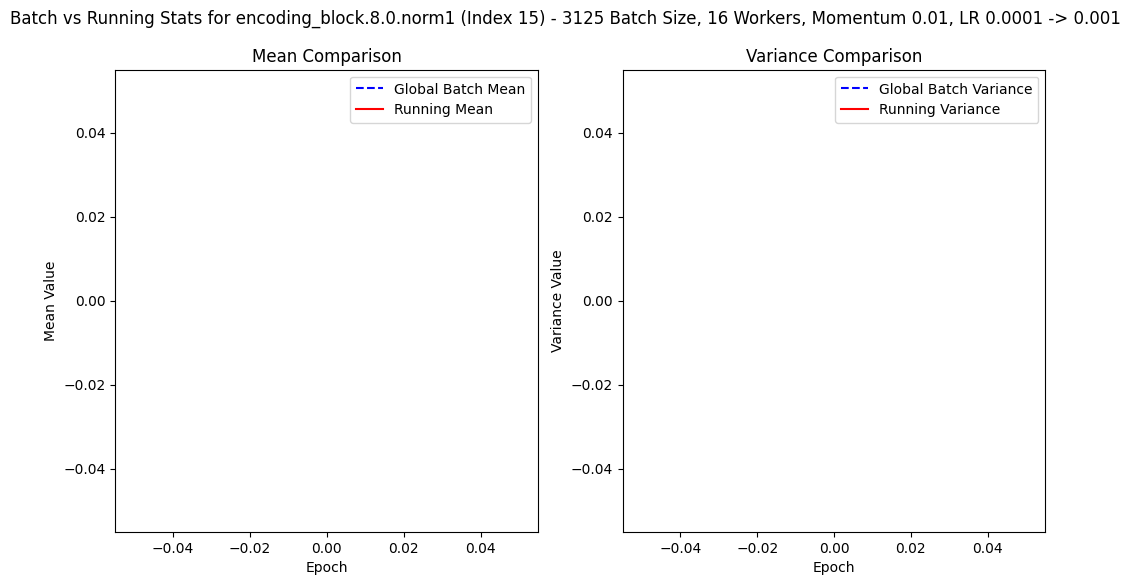

In [13]:
import ast 
def plot_batch_vs_running_stats(batch_stats_log, layer_name, sample, index=1):

    epochs = []
    global_batch_mean = []
    global_batch_var = []
    running_mean = []
    running_var = []
    with open(batch_stats_log, 'r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            if str(row['layer_name']) == layer_name:
                epochs.append(int(row['epoch']))
                global_batch_mean_list = ast.literal_eval(str(row['global_batch_mean'].split()[1:-2]))
                global_batch_mean_arr = np.array([float(g) for g in global_batch_mean_list])
                global_batch_mean.append(float(global_batch_mean_arr[index]))
                global_batch_var_list = ast.literal_eval(str(row['global_batch_var'].split()[1:-2]))
                global_batch_var_arr = np.array([float(g) for g in global_batch_var_list])
                global_batch_var.append(float(global_batch_var_arr[index]))
                running_mean_list = ast.literal_eval(str(row['running_mean'].split()[1:-2]))
                running_mean_arr = np.array([float(g) for g in running_mean_list])
                running_mean.append(float(running_mean_arr[index]))
                running_var_list = ast.literal_eval(str(row['running_var'].split()[1:-2]))
                running_var_arr = np.array([float(g) for g in running_var_list])
                running_var.append(float(running_var_arr[index]))
            else: continue

    fig, ax = plt.subplots(1, 2, figsize=(12,6))
    fig.suptitle(f'Batch vs Running Stats for {layer_name} (Index {index}) - ' + sample)
    ax[0].plot(epochs, global_batch_mean, label='Global Batch Mean', color='blue', linestyle='--')
    ax[0].plot(epochs, running_mean, label='Running Mean', color='red', linestyle='-')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Mean Value')
    ax[0].set_title(f'Mean Comparison')
    ax[0].legend()      

    ax[1].plot(epochs, global_batch_var, label='Global Batch Variance', color='blue', linestyle='--')
    ax[1].plot(epochs, running_var, label='Running Variance', color='red', linestyle='-')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('Variance Value')
    ax[1].set_title(f'Variance Comparison')
    ax[1].legend()
    plt.show()      

plot_batch_vs_running_stats(batch_stats_log, 'encoding_block.2.1.norm2', '3125 Batch Size, 16 Workers, Momentum 0.01, LR 0.0001 -> 0.001', index=0)
plot_batch_vs_running_stats(batch_stats_log, 'encoding_block.2.1.norm2', '3125 Batch Size, 16 Workers, Momentum 0.01, LR 0.0001 -> 0.001', index=1)
plot_batch_vs_running_stats(batch_stats_log, 'encoding_block.2.1.norm2', '3125 Batch Size, 16 Workers, Momentum 0.01, LR 0.0001 -> 0.001', index=2)
plot_batch_vs_running_stats(batch_stats_log, 'encoding_block.2.1.norm2', '3125 Batch Size, 16 Workers, Momentum 0.01, LR 0.0001 -> 0.001', index=3)
plot_batch_vs_running_stats(batch_stats_log, 'encoding_block.2.1.norm2', '3125 Batch Size, 16 Workers, Momentum 0.01, LR 0.0001 -> 0.001', index=4)
plot_batch_vs_running_stats(batch_stats_log, 'encoding_block.2.1.norm2', '3125 Batch Size, 16 Workers, Momentum 0.01, LR 0.0001 -> 0.001', index=5)

plot_batch_vs_running_stats(batch_stats_log, 'encoding_block.8.0.norm1', '3125 Batch Size, 16 Workers, Momentum 0.01, LR 0.0001 -> 0.001', index=10)
plot_batch_vs_running_stats(batch_stats_log, 'encoding_block.8.0.norm1', '3125 Batch Size, 16 Workers, Momentum 0.01, LR 0.0001 -> 0.001', index=11)
plot_batch_vs_running_stats(batch_stats_log, 'encoding_block.8.0.norm1', '3125 Batch Size, 16 Workers, Momentum 0.01, LR 0.0001 -> 0.001', index=12)
plot_batch_vs_running_stats(batch_stats_log, 'encoding_block.8.0.norm1', '3125 Batch Size, 16 Workers, Momentum 0.01, LR 0.0001 -> 0.001', index=13)
plot_batch_vs_running_stats(batch_stats_log, 'encoding_block.8.0.norm1', '3125 Batch Size, 16 Workers, Momentum 0.01, LR 0.0001 -> 0.001', index=14)
plot_batch_vs_running_stats(batch_stats_log, 'encoding_block.8.0.norm1', '3125 Batch Size, 16 Workers, Momentum 0.01, LR 0.0001 -> 0.001', index=15)



In [14]:
# Load model with eval mode off
'''torch.cuda.empty_cache()
# Get parameters
yaml_config = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/configs/default_sheep.yaml'
config = 'default'
params = ParseYAML(os.path.abspath(yaml_config), config)

# Initialize model 
if torch.cuda.is_available():
    device = torch.cuda.current_device()
else:
    device = torch.device('cpu')

model = models.sheep_cnn.sheep_cnn(params).to(device)
#model = torch.nn.SyncBatchNorm.convert_sync_batchnorm(model)

# get model dictionary
#checkpoint_path = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_CHECK_REPRO_3A/checkpoints/ckpt_epoch_5_iters1500.tar'
#checkpoint_path = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_OFF_3C/checkpoints/ckpt_epoch_5_iters1500.tar'
checkpoint_path = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_ON_SYNC_BN_MOMENTUM_0.01_LOG_BN_STATS_4D/checkpoints/ckpt_epoch_0_iters_250_best.tar'


checkpoint = torch.load(checkpoint_path, weights_only=True) 
try:
    model.load_state_dict(checkpoint['model_state'])
except:
    new_state_dict = OrderedDict()
    for key, val in checkpoint['model_state'].items():
        name = key[7:]
        new_state_dict[name] = val 
    model.load_state_dict(new_state_dict)'''


"torch.cuda.empty_cache()\n# Get parameters\nyaml_config = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/configs/default_sheep.yaml'\nconfig = 'default'\nparams = ParseYAML(os.path.abspath(yaml_config), config)\n\n# Initialize model \nif torch.cuda.is_available():\n    device = torch.cuda.current_device()\nelse:\n    device = torch.device('cpu')\n\nmodel = models.sheep_cnn.sheep_cnn(params).to(device)\n#model = torch.nn.SyncBatchNorm.convert_sync_batchnorm(model)\n\n# get model dictionary\n#checkpoint_path = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_CHECK_REPRO_3A/checkpoints/ckpt_epoch_5_iters1500.tar'\n#checkpoint_path = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_OFF_3C/checkpoin

In [15]:
# Look at parameters
'''print("Model's state_dict:")
for param_tensor in model.state_dict():
    print(param_tensor, "\t", model.state_dict()[param_tensor].size())'''

'print("Model\'s state_dict:")\nfor param_tensor in model.state_dict():\n    print(param_tensor, "\t", model.state_dict()[param_tensor].size())'

In [16]:
# Look at parameters
'''print("Model's state_dict:")
for param_tensor in model.state_dict():
    if "bn" in param_tensor:
        print(param_tensor, "\t", model.state_dict()[param_tensor])'''

'print("Model\'s state_dict:")\nfor param_tensor in model.state_dict():\n    if "bn" in param_tensor:\n        print(param_tensor, "\t", model.state_dict()[param_tensor])'